# Proyecto Simulación 

## Iron condor asimétrico SPY

[*] Usando datos estáticos del 28 de abril para generar gráficas del reporte...
Parámetros: S0=$718.66, r=5.0%, T=45 días

Volatilidades Implícitas Individuales (El verdadero Skew):
Sigma Long Put  (647): 22.80%
Sigma Short Put (661): 20.94%
Sigma Short Call(747): 13.77%
Sigma Long Call (762): 12.77%

[-] Compra Put  (Strike 647): Precio Teórico = $2.0427
[+] Venta Put   (Strike 661): Precio Teórico = $2.7112
[+] Venta Call  (Strike 747): Precio Teórico = $5.2848
[-] Compra Call (Strike 762): Precio Teórico = $1.9786
----------------------------------------------------------------------
Prima cobrada     : $3.97 (Ganancia Máxima)
Pérdida máxima    : $10.03
Zona de ganancia  : [661, 747]


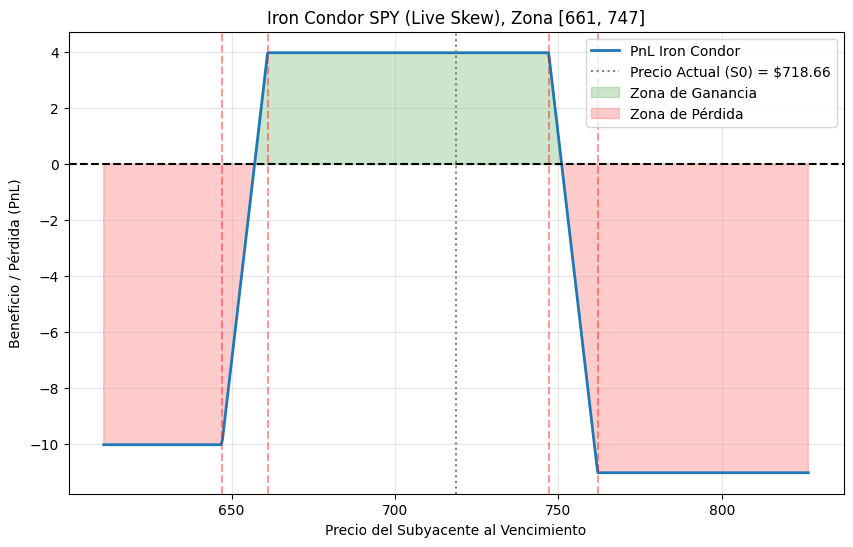

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
from datetime import datetime, timedelta

# ==========================================================
# 1. FUNCIONES BASE (Black-Scholes y Gráficas)
# ==========================================================
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """Calcula el precio teórico usando Black-Scholes."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

def payoff_estrategia(S_range, legs):
    """Calcula el PnL para un rango de precios."""
    pnl = np.zeros_like(S_range)
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl += leg['posicion'] * (payoff - leg['prima'])
    return pnl

def graficar_estrategia(S_range, pnl, titulo, S0, K_lines):
    """Genera el gráfico de beneficios y pérdidas."""
    plt.figure(figsize=(10, 6))
    plt.plot(S_range, pnl, label='PnL Iron Condor', color='#1f77b4', linewidth=2)
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(S0, color='gray', linestyle=':', label=f'Precio Actual (S0) = ${S0:.2f}')

    for K, label_text in K_lines:
        plt.axvline(K, color='red', linestyle='--', alpha=0.4)

    plt.fill_between(S_range, pnl, 0, where=(pnl >= 0), color='green', alpha=0.2, label='Zona de Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), color='red', alpha=0.2, label='Zona de Pérdida')

    plt.title(titulo)
    plt.xlabel('Precio del Subyacente al Vencimiento')
    plt.ylabel('Beneficio / Pérdida (PnL)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================================
# 2. VALORES CONGELADOS (28 de abril para coherencia del reporte)
# ==========================================================
print("[*] Usando datos estáticos del 28 de abril para generar gráficas del reporte...")

S0 = 718.66 # Precio congelado
r = 0.05
dias_vencimiento = 45
T = dias_vencimiento / 365

# STRIKES FIJOS (calculados previamente)
K_pl = 647
K_ps = 661
K_cs = 747
K_cl = 762

# VOLATILIDADES IMPLÍCITAS FIJAS (El Skew de su avance)
sigma_pl = 0.2280
sigma_ps = 0.2094
sigma_cs = 0.1377
sigma_cl = 0.1277
# ==========================================================
# 3. CÁLCULO DE PRECIOS TEÓRICOS (BLACK-SCHOLES)
# ==========================================================
# Ahora cada pata usa su propia volatilidad exacta (La verdadera curva del Skew)
P_l = black_scholes(S0, K_pl, T, r, sigma_pl, 'put')
P_s = black_scholes(S0, K_ps, T, r, sigma_ps, 'put')
C_s = black_scholes(S0, K_cs, T, r, sigma_cs, 'call')
C_l = black_scholes(S0, K_cl, T, r, sigma_cl, 'call')

# ==========================================================
# 4. REPORTE EN CONSOLA
# ==========================================================
print("=" * 70)
print("=" * 70)
print(f"Parámetros: S0=${S0:.2f}, r={r*100}%, T={dias_vencimiento} días")
print("\nVolatilidades Implícitas Individuales (El verdadero Skew):")
print(f"Sigma Long Put  ({K_pl}): {sigma_pl*100:.2f}%")
print(f"Sigma Short Put ({K_ps}): {sigma_ps*100:.2f}%")
print(f"Sigma Short Call({K_cs}): {sigma_cs*100:.2f}%")
print(f"Sigma Long Call ({K_cl}): {sigma_cl*100:.2f}%\n")

print(f"[-] Compra Put  (Strike {K_pl}): Precio Teórico = ${P_l:.4f}")
print(f"[+] Venta Put   (Strike {K_ps}): Precio Teórico = ${P_s:.4f}")
print(f"[+] Venta Call  (Strike {K_cs}): Precio Teórico = ${C_s:.4f}")
print(f"[-] Compra Call (Strike {K_cl}): Precio Teórico = ${C_l:.4f}")
print("-" * 70)

# ==========================================================
# 5. LÓGICA Y GRÁFICA
# ==========================================================
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"Prima cobrada     : ${prima_cobrada:.2f} (Ganancia Máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps}, {K_cs}]")
print("=" * 70)

graficar_estrategia(S_range, pnl,
                    f'Iron Condor SPY (Live Skew), Zona [{K_ps}, {K_cs}]', S0=S0,
                    K_lines=[(K_pl,f'{K_pl}'),(K_ps,f'{K_ps}'),
                             (K_cs,f'{K_cs}'),(K_cl,f'{K_cl}')])

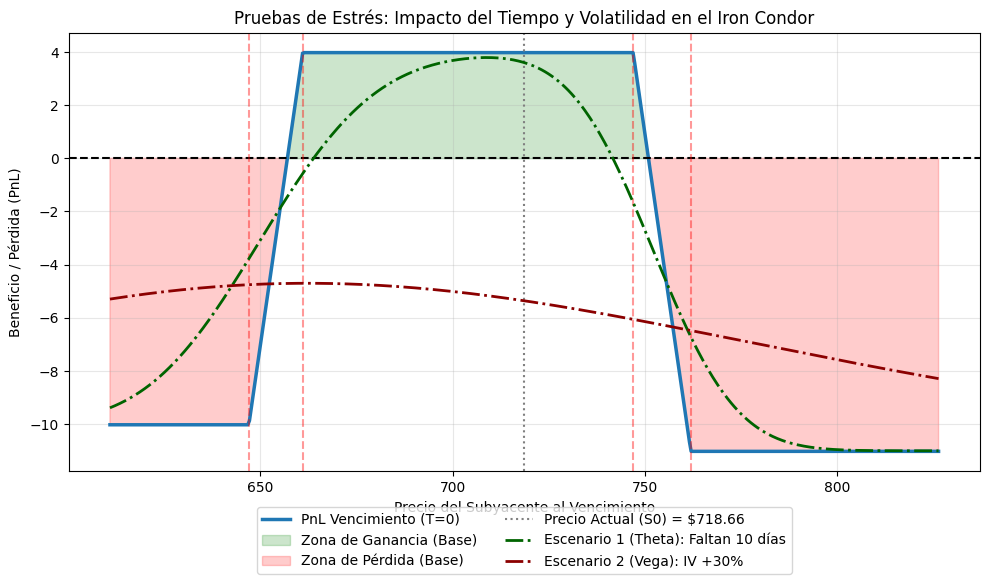

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================================
# 1. FUNCIÓN BLACK-SCHOLES
# ==========================================================
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """Calcula el precio teórico usando Black-Scholes."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

# ==========================================================
# 2. DATOS CONGELADOS (Avance del 28 de abril)
# ==========================================================
S0 = 718.66
r = 0.05
dias_vencimiento_base = 45
T_base = dias_vencimiento_base / 365

# Strikes de la estrategia
K_pl, K_ps, K_cs, K_cl = 647, 661, 747, 762

# Volatilidades Implícitas (Skew Real extraído previamente)
sigma_pl, sigma_ps, sigma_cs, sigma_cl = 0.2280, 0.2094, 0.1377, 0.1277

# Precios iniciales (T=45 días)
P_l = black_scholes(S0, K_pl, T_base, r, sigma_pl, 'put')
P_s = black_scholes(S0, K_ps, T_base, r, sigma_ps, 'put')
C_s = black_scholes(S0, K_cs, T_base, r, sigma_cs, 'call')
C_l = black_scholes(S0, K_cl, T_base, r, sigma_cl, 'call')

prima_cobrada = (P_s - P_l) + (C_s - C_l)

# ==========================================================
# 3. LÓGICA DE SIMULACIÓN Y ESCENARIOS
# ==========================================================
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)

legs = [
    {'tipo': 'put',  'K': K_pl, 'sigma': sigma_pl, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'sigma': sigma_ps, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'sigma': sigma_cs, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'sigma': sigma_cl, 'posicion': +1},
]

# A. PAYOFF AL VENCIMIENTO (T=0)
pnl_vencimiento = np.zeros_like(S_range)
for leg in legs:
    if leg['tipo'] == 'call':
        payoff = np.maximum(S_range - leg['K'], 0)
    else:
        payoff = np.maximum(leg['K'] - S_range, 0)
    pnl_vencimiento += leg['posicion'] * payoff
pnl_vencimiento += prima_cobrada

# B. ESCENARIO 1: Efecto Theta (Faltan 10 días para expirar)
dias_restantes_e1 = 10
T_e1 = dias_restantes_e1 / 365
pnl_escenario1 = np.zeros_like(S_range)
for leg in legs:
    precio = black_scholes(S_range, leg['K'], T_e1, r, leg['sigma'], leg['tipo'])
    pnl_escenario1 += leg['posicion'] * precio
pnl_escenario1 += prima_cobrada

# C. ESCENARIO 2: Efecto Vega (Pánico, IV salta +30% absoluto, siguen faltando 45 días)
choque_vol = 0.30
pnl_escenario2 = np.zeros_like(S_range)
for leg in legs:
    precio = black_scholes(S_range, leg['K'], T_base, r, leg['sigma'] + choque_vol, leg['tipo'])
    pnl_escenario2 += leg['posicion'] * precio
pnl_escenario2 += prima_cobrada

# ==========================================================
# 4. GRÁFICA COMPARATIVA (CON ESTILO ORIGINAL)
# ==========================================================
plt.figure(figsize=(10, 6))

# Línea base y rellenos (Estilo original)
plt.plot(S_range, pnl_vencimiento, label='PnL Vencimiento (T=0)', color='#1f77b4', linewidth=2.5)
plt.fill_between(S_range, pnl_vencimiento, 0, where=(pnl_vencimiento >= 0), color='green', alpha=0.2, label='Zona de Ganancia (Base)')
plt.fill_between(S_range, pnl_vencimiento, 0, where=(pnl_vencimiento < 0), color='red', alpha=0.2, label='Zona de Pérdida (Base)')

# Línea Cero y Precio Actual
plt.axhline(0, color='black', linestyle='--')
plt.axvline(S0, color='gray', linestyle=':', label=f'Precio Actual (S0) = ${S0:.2f}')

# Líneas de los Strikes
for K in [K_pl, K_ps, K_cs, K_cl]:
    plt.axvline(K, color='red', linestyle='--', alpha=0.4)

# Curvas de los nuevos escenarios
plt.plot(S_range, pnl_escenario1, label=f'Escenario 1 (Theta): Faltan {dias_restantes_e1} días', color='darkgreen', linestyle='-.', linewidth=2)
plt.plot(S_range, pnl_escenario2, label='Escenario 2 (Vega): IV +30%', color='darkred', linestyle='-.', linewidth=2)

plt.title('Pruebas de Estrés: Impacto del Tiempo y Volatilidad en el Iron Condor')
plt.xlabel('Precio del Subyacente al Vencimiento')
plt.ylabel('Beneficio / Pérdida (PnL)')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()